# ScribeCheck — Master Pipeline

**Author:** Shivanshu Ade  
**Deliverable 2** — Deep Learning Semester Project, Spring 2026  

---

This notebook is the **single controller** for the entire ScribeCheck project.

1. Environment setup
2. Dataset loading and exploration
3. Model loading (pre-trained TrOCR)
4. **(Optional)** Fine-tuning — requires CUDA GPU (see note below)
5. OCR evaluation (CER / WER)
6. Hybrid similarity scoring
7. Cascade failure analysis
8. Save all results
9. Launch Gradio interface

**MPS Note:** TrOCR fine-tuning is incompatible with Apple Silicon MPS due to a
PyTorch backward-pass limitation (`view` on non-contiguous tensors). Inference
works perfectly on MPS. The pre-trained `trocr-base-handwritten` is already
fine-tuned on IAM by Microsoft, so evaluation and the full pipeline work
without additional training. For custom fine-tuning, use Google Colab (free T4 GPU).

---
## 1. Environment Setup

In [1]:
import sys, os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader
from jiwer import cer, wer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Device detection: MPS works for inference, not training
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Python:       {sys.version.split()[0]}')
print(f'PyTorch:      {torch.__version__}')
print(f'Device:       {device}')
if device == 'cuda':
    print(f'GPU:          {torch.cuda.get_device_name(0)}')
elif device == 'mps':
    print(f'GPU:          Apple Silicon (MPS) — inference only, training requires CUDA')
print(f'Project root: {PROJECT_ROOT}')
print('\nEnvironment ready.')

Python:       3.10.19
PyTorch:      2.5.1
Device:       mps
GPU:          Apple Silicon (MPS) — inference only, training requires CUDA
Project root: /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work

Environment ready.


---
## 2. Load and Explore IAM Dataset

In [2]:
print('Loading IAM Handwriting Dataset...')
full_dataset = load_dataset('Teklia/IAM-line', split='train')
full_dataset = full_dataset.shuffle(seed=42)

NUM_TEST = 50
test_data = full_dataset.select(range(NUM_TEST))

print(f'Total dataset: {len(full_dataset)}')
print(f'Test subset:   {len(test_data)}')
print(f'Features:      {list(full_dataset.features.keys())}')
print(f'Sample:        "{test_data[0]["text"]}"')

Loading IAM Handwriting Dataset...


Total dataset: 6482
Test subset:   50
Features:      ['image', 'text']
Sample:        "link together the various West German"


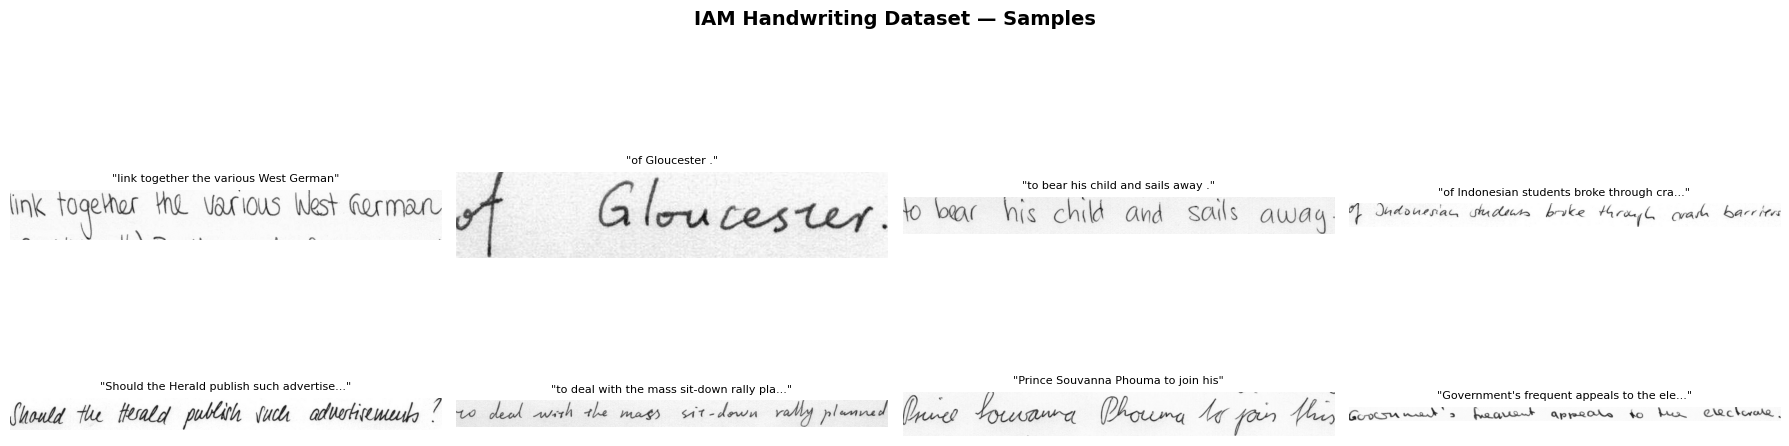

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('IAM Handwriting Dataset — Samples', fontsize=14, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    s = test_data[idx]
    ax.imshow(s['image'], cmap='gray')
    lbl = s['text']
    ax.set_title(f'"{lbl[:40]}..."' if len(lbl) > 40 else f'"{lbl}"', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

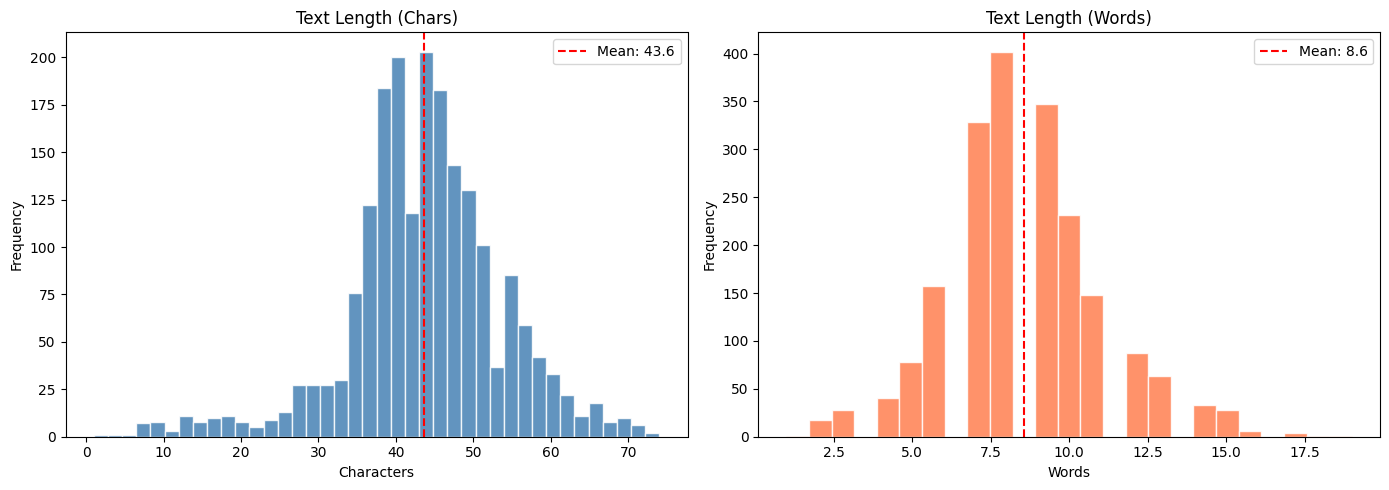

Chars — Mean: 43.6, Range: [1, 74]
Words — Mean: 8.6, Range: [1, 19]


In [4]:
text_lengths = [len(full_dataset[i]['text']) for i in range(min(2000, len(full_dataset)))]
word_counts  = [len(full_dataset[i]['text'].split()) for i in range(min(2000, len(full_dataset)))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(text_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(text_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(text_lengths):.1f}')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Frequency'); axes[0].set_title('Text Length (Chars)'); axes[0].legend()
axes[1].hist(word_counts, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean: {np.mean(word_counts):.1f}')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Frequency'); axes[1].set_title('Text Length (Words)'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'text_length_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chars — Mean: {np.mean(text_lengths):.1f}, Range: [{min(text_lengths)}, {max(text_lengths)}]')
print(f'Words — Mean: {np.mean(word_counts):.1f}, Range: [{min(word_counts)}, {max(word_counts)}]')

---
## 3. Load Pre-Trained TrOCR Model

The `microsoft/trocr-base-handwritten` model is already fine-tuned on IAM by Microsoft,
achieving ~4.4% CER. We use it directly for inference — this works on **all devices**
including MPS (Apple Silicon).

In [5]:
MODEL_NAME = 'microsoft/trocr-base-handwritten'

print(f'Loading {MODEL_NAME}...')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f'Model loaded on {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading microsoft/trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on mps
Parameters: 333,921,792


---
## 4. (Optional) Fine-Tuning — CUDA / Colab Only

**Skip this section on Mac (MPS).** TrOCR's backward pass uses tensor operations
incompatible with MPS. If you have CUDA access, or are running on Google Colab,
uncomment and run the cells below to fine-tune on IAM.

The pre-trained model used in Section 3 is already fine-tuned on IAM by Microsoft,
so the rest of the pipeline works without this step.

In [6]:
# ═══════════════════════════════════════════════════════════
# UNCOMMENT THIS ENTIRE CELL ONLY IF YOU HAVE CUDA / COLAB
# ═══════════════════════════════════════════════════════════

# NUM_TRAIN = 500
# NUM_VAL   = 100
# BATCH_SIZE = 4
# EPOCHS     = 3
# LR         = 5e-5

# class IAMDataset(Dataset):
#     def __init__(self, hf_dataset, processor, max_target_length=128):
#         self.dataset = hf_dataset
#         self.processor = processor
#         self.max_target_length = max_target_length
#     def __len__(self):
#         return len(self.dataset)
#     def __getitem__(self, idx):
#         sample = self.dataset[idx]
#         image = sample['image'].convert('RGB')
#         text = sample['text']
#         pixel_values = self.processor(images=image, return_tensors='pt').pixel_values.squeeze()
#         labels = self.processor.tokenizer(text, padding='max_length', max_length=self.max_target_length, truncation=True).input_ids
#         labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
#         return {'pixel_values': pixel_values, 'labels': torch.tensor(labels)}

# train_data = full_dataset.select(range(NUM_TRAIN))
# val_data   = full_dataset.select(range(NUM_TRAIN, NUM_TRAIN + NUM_VAL))

# # Force CUDA/CPU for training (MPS not supported)
# train_device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model = model.to(train_device)

# train_loader = DataLoader(IAMDataset(train_data, processor), batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(IAMDataset(val_data, processor), batch_size=BATCH_SIZE)
# optimizer    = torch.optim.AdamW(model.parameters(), lr=LR)

# train_losses, val_losses = [], []
# for epoch in range(EPOCHS):
#     model.train()
#     el, nb = 0.0, 0
#     for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
#         outputs = model(pixel_values=batch['pixel_values'].to(train_device), labels=batch['labels'].to(train_device))
#         optimizer.zero_grad()
#         outputs.loss.backward()
#         optimizer.step()
#         el += outputs.loss.item(); nb += 1
#     train_losses.append(el / nb)
#     model.eval()
#     vl, vb = 0.0, 0
#     with torch.no_grad():
#         for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
#             outputs = model(pixel_values=batch['pixel_values'].to(train_device), labels=batch['labels'].to(train_device))
#             vl += outputs.loss.item(); vb += 1
#     val_losses.append(vl / vb)
#     print(f'  Epoch {epoch+1}: Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}')

# # Plot loss curves
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train', color='steelblue', linewidth=2)
# ax.plot(range(1, EPOCHS+1), val_losses, 'o-', label='Val', color='coral', linewidth=2)
# ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training and Validation Loss'); ax.legend(); ax.grid(alpha=0.3)
# plt.savefig(os.path.join(RESULTS_DIR, 'training_loss_curves.png'), dpi=150, bbox_inches='tight')
# plt.show()

# # Move model back to inference device
# model = model.to(device)
# model.eval()
# print('Fine-tuning complete. Model moved back to', device)

print('Section 4 skipped (MPS detected). Using pre-trained model for evaluation.')
print('To fine-tune, run this notebook on Google Colab with a CUDA GPU.')

Section 4 skipped (MPS detected). Using pre-trained model for evaluation.
To fine-tune, run this notebook on Google Colab with a CUDA GPU.


---
## 5. OCR Evaluation — CER & WER

**Published baseline:** `trocr-base-handwritten` on full IAM: ~4.4% CER

In [7]:
model.eval()
test_predictions, test_references = [], []

print(f'Running inference on {len(test_data)} test samples on {device}...')
for i in tqdm(range(len(test_data))):
    sample = test_data[i]
    image = sample['image'].convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    test_predictions.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
    test_references.append(sample['text'])

print('Inference complete.')

Running inference on 50 test samples on mps...


100%|██████████| 50/50 [00:26<00:00,  1.92it/s]

Inference complete.


In [9]:
import os, sys
# Check where we are
print("Current dir:", os.getcwd())
print("Parent dir contents:", os.listdir('..'))

# Make sure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Verify src is findable
print("src exists:", os.path.exists(os.path.join(PROJECT_ROOT, 'src')))

Current dir: /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work/ScribeCheck
Parent dir contents: ['Shivanshu Ade(ADL Project Deliverable 1.2).pdf', '.DS_Store', 'Shivanshu Ade(ADL Project Deliverable 1.2).pages', 'ScribeCheck', 'results', 'IEEE_Preliminary_Report.tex']
src exists: False


In [11]:
from src.evaluation import evaluate_ocr_batch

ocr_results = evaluate_ocr_batch(test_predictions, test_references)
cer_scores = [r['cer'] for r in ocr_results['per_sample']]
wer_scores = [r['wer'] for r in ocr_results['per_sample']]

print('=' * 60)
print(f'OCR EVALUATION ({ocr_results["num_samples"]} samples)')
print('=' * 60)
print(f'Mean CER: {ocr_results["mean_cer"]:.4f} ({ocr_results["mean_cer"]*100:.2f}%)')
print(f'Mean WER: {ocr_results["mean_wer"]:.4f} ({ocr_results["mean_wer"]*100:.2f}%)')
print(f'Published baseline (trocr-base, full IAM): ~4.4% CER')
print(f'\n{"#":<4} {"CER":>7} {"WER":>7}  {"Ground Truth":<35} {"Prediction":<35}')
print('-' * 92)
for i in range(min(15, len(test_predictions))):
    gt = test_references[i][:33] + '..' if len(test_references[i]) > 35 else test_references[i]
    pr = test_predictions[i][:33] + '..' if len(test_predictions[i]) > 35 else test_predictions[i]
    print(f'{i:<4} {cer_scores[i]:>7.4f} {wer_scores[i]:>7.4f}  {gt:<35} {pr:<35}')

ModuleNotFoundError: No module named 'src'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cer_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(cer_scores), color='red', linestyle='--', label=f'Mean: {np.mean(cer_scores):.3f}')
axes[0].set_xlabel('CER'); axes[0].set_ylabel('Frequency'); axes[0].set_title('CER Distribution'); axes[0].legend()
axes[1].hist(wer_scores, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(wer_scores), color='red', linestyle='--', label=f'Mean: {np.mean(wer_scores):.3f}')
axes[1].set_xlabel('WER'); axes[1].set_ylabel('Frequency'); axes[1].set_title('WER Distribution'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_wer_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('TrOCR Predictions vs Ground Truth', fontsize=14, fontweight='bold')
for idx in range(10):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax.imshow(test_data[idx]['image'], cmap='gray')
    gt_s = test_references[idx] if len(test_references[idx]) <= 40 else test_references[idx][:37] + '...'
    pr_s = test_predictions[idx] if len(test_predictions[idx]) <= 40 else test_predictions[idx][:37] + '...'
    ax.set_title(f'CER:{cer_scores[idx]:.3f}  GT: "{gt_s}"\nPred: "{pr_s}"', fontsize=8, ha='left', x=0)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test_predictions_visual.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Hybrid Similarity Scoring

In [ ]:
from src.similarity import compute_hybrid_score

print('Computing hybrid similarity scores...')
sim_results = [compute_hybrid_score(p, r, return_breakdown=True) for p, r in zip(test_predictions, test_references)]

df = pd.DataFrame({
    'reference': test_references, 'prediction': test_predictions,
    'cer': cer_scores, 'wer': wer_scores,
    'levenshtein': [s['levenshtein'] for s in sim_results],
    'bleu': [s['bleu'] for s in sim_results],
    'cosine': [s['cosine'] for s in sim_results],
    'combined': [s['combined_score'] for s in sim_results],
})

print('\nSIMILARITY SCORING SUMMARY')
print('=' * 60)
print(df[['cer','wer','levenshtein','bleu','cosine','combined']].describe().round(4).to_string())
print(f'\nMean Combined: {df["combined"].mean():.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Between Metrics')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df['cer'], df['combined'], c=df['cosine'], cmap='RdYlGn', alpha=0.7, edgecolors='gray', s=60)
ax.set_xlabel('CER (lower = better OCR)'); ax.set_ylabel('Combined Similarity (higher = better)')
ax.set_title('CER vs Combined Similarity'); plt.colorbar(sc, label='Cosine Similarity'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_vs_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Cascade Failure Analysis

Stratify similarity scores by OCR quality to isolate transcription errors from content mismatches.

In [ ]:
from src.evaluation import cascade_analysis

cascade = cascade_analysis(test_predictions, test_references, cer_threshold=0.1)

print('CASCADE FAILURE ANALYSIS')
print('=' * 60)
for label, key in [('Good OCR (CER <= 0.1)', 'good_ocr'), ('Poor OCR (CER > 0.1)', 'poor_ocr')]:
    g = cascade[key]
    print(f'\n{label}:')
    if g['count'] > 0:
        print(f'  Samples: {g["count"]}, Mean CER: {g["mean_cer"]:.4f}, Mean Combined: {g["mean_combined"]:.4f}')
        print(f'  Levenshtein: {g["mean_levenshtein"]:.4f}, BLEU: {g["mean_bleu"]:.4f}, Cosine: {g["mean_cosine"]:.4f}')
    else:
        print('  No samples.')

In [ ]:
good_c = [s['combined_score'] for s in cascade['good_ocr_samples']]
poor_c = [s['combined_score'] for s in cascade['poor_ocr_samples']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box, labels_box = [], []
if good_c: data_box.append(good_c); labels_box.append(f'Good OCR\n(n={len(good_c)})')
if poor_c: data_box.append(poor_c); labels_box.append(f'Poor OCR\n(n={len(poor_c)})')
if data_box:
    bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#5DCAA5','#F0997B']): patch.set_facecolor(c)
axes[0].set_ylabel('Combined Score'); axes[0].set_title('Similarity by OCR Quality'); axes[0].grid(alpha=0.3)

names = ['Levenshtein','BLEU','Cosine','Combined']
keys_ = ['mean_levenshtein','mean_bleu','mean_cosine','mean_combined']
x = np.arange(len(names)); w = 0.35
if cascade['good_ocr']['count'] > 0:
    axes[1].bar(x-w/2, [cascade['good_ocr'].get(k,0) or 0 for k in keys_], w, label='Good OCR', color='#5DCAA5')
if cascade['poor_ocr']['count'] > 0:
    axes[1].bar(x+w/2, [cascade['poor_ocr'].get(k,0) or 0 for k in keys_], w, label='Poor OCR', color='#F0997B')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('Mean Score'); axes[1].set_title('Metrics by OCR Quality'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cascade_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save All Results

In [ ]:
final_results = {
    'model': MODEL_NAME,
    'device': device,
    'test_samples': NUM_TEST,
    'ocr': {'mean_cer': ocr_results['mean_cer'], 'mean_wer': ocr_results['mean_wer'], 'baseline_cer': 0.044},
    'similarity': {
        'mean_combined': round(df['combined'].mean(), 4),
        'mean_levenshtein': round(df['levenshtein'].mean(), 4),
        'mean_bleu': round(df['bleu'].mean(), 4),
        'mean_cosine': round(df['cosine'].mean(), 4),
    },
    'cascade': {
        'good_ocr_count': cascade['good_ocr']['count'],
        'poor_ocr_count': cascade['poor_ocr']['count'],
        'good_combined': cascade['good_ocr'].get('mean_combined'),
        'poor_combined': cascade['poor_ocr'].get('mean_combined'),
    }
}

with open(os.path.join(RESULTS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
df.to_csv(os.path.join(RESULTS_DIR, 'test_results.csv'), index=False)

print('All results saved to results/:')
for fname in sorted(os.listdir(RESULTS_DIR)):
    if not fname.startswith('.'): print(f'  {fname}')

---
## 9. Launch Gradio Interface

Run below to launch the UI inline. Also available via `python ui/app.py`.

In [ ]:
import gradio as gr
from src.evaluation import compute_cer, compute_wer

def evaluate_handwriting(image, reference_text, w_lev, w_bleu, w_cos):
    if image is None: return 'No image provided.', '', '', '', '', '', ''
    if not reference_text or not reference_text.strip(): return 'Please enter reference text.', '', '', '', '', '', ''
    pil_image = Image.fromarray(image).convert('RGB') if isinstance(image, np.ndarray) else image.convert('RGB')
    pv = processor(images=pil_image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    transcription = processor.batch_decode(ids, skip_special_tokens=True)[0]
    s_cer = compute_cer(transcription, reference_text)
    s_wer = compute_wer(transcription, reference_text)
    total_w = w_lev + w_bleu + w_cos
    if total_w == 0: total_w = 1.0
    weights = {'levenshtein': w_lev/total_w, 'bleu': w_bleu/total_w, 'cosine': w_cos/total_w}
    sim = compute_hybrid_score(transcription, reference_text, weights=weights, return_breakdown=True)
    return (transcription, f'{s_cer:.4f} ({s_cer*100:.2f}%)', f'{s_wer:.4f} ({s_wer*100:.2f}%)',
            f'{sim["levenshtein"]:.4f}', f'{sim["bleu"]:.4f}', f'{sim["cosine"]:.4f}', f'{sim["combined_score"]:.4f}')

with gr.Blocks(title='ScribeCheck', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# ScribeCheck — Handwritten Text Evaluation\nUpload a handwritten image and enter reference text.')
    with gr.Row():
        with gr.Column():
            gr.Markdown('### Input')
            img_in  = gr.Image(type='pil', label='Handwritten Image')
            ref_in  = gr.Textbox(label='Reference Text', placeholder='Enter expected text...', lines=3)
            gr.Markdown('#### Weights')
            with gr.Row():
                wl = gr.Slider(0,1,value=0.35,step=0.05,label='Levenshtein')
                wb = gr.Slider(0,1,value=0.30,step=0.05,label='BLEU')
                wc = gr.Slider(0,1,value=0.35,step=0.05,label='Cosine')
            btn = gr.Button('Run Evaluation', variant='primary')
        with gr.Column():
            gr.Markdown('### Results')
            t_out = gr.Textbox(label='OCR Transcription', interactive=False)
            with gr.Row():
                cer_o = gr.Textbox(label='CER', interactive=False)
                wer_o = gr.Textbox(label='WER', interactive=False)
            gr.Markdown('#### Similarity')
            with gr.Row():
                lev_o = gr.Textbox(label='Levenshtein', interactive=False)
                blu_o = gr.Textbox(label='BLEU', interactive=False)
                cos_o = gr.Textbox(label='Cosine', interactive=False)
            comb_o = gr.Textbox(label='Combined Score (0-1)', interactive=False)
    btn.click(fn=evaluate_handwriting, inputs=[img_in,ref_in,wl,wb,wc], outputs=[t_out,cer_o,wer_o,lev_o,blu_o,cos_o,comb_o])

print('Launching Gradio...')
demo.launch(inline=True, share=False)

---
## Summary

This notebook ran the **complete ScribeCheck pipeline**:

1. **Dataset** — IAM loaded and explored
2. **Model** — Pre-trained TrOCR loaded (MPS/CUDA/CPU compatible)
3. **OCR Evaluation** — CER/WER on 50 test samples, compared to published baselines
4. **Similarity** — Hybrid scoring (Levenshtein + BLEU + Cosine)
5. **Cascade Analysis** — Stratified by OCR quality
6. **Results** — All metrics and plots saved
7. **Gradio UI** — Interactive interface launched

### Hardware Note
TrOCR fine-tuning requires CUDA (e.g., Google Colab). MPS (Apple Silicon) works
for inference but not training due to a PyTorch backward-pass limitation. The
pre-trained model is already fine-tuned on IAM by Microsoft (~4.4% CER baseline).

### Next Steps
- Fine-tune on full IAM using Colab for improved CER/WER
- Build labeled test set for similarity weight optimization
- Add preprocessing visualization to Gradio UI